# Week 45

In [1]:
import numpy as np
import pandas as pd
from scipy.io import savemat
from scipy.sparse import csr_matrix

def tier_c_weight(m_pred_g, m_prey_g, mu=2.0, sigma=0.7, eps=1e-9):
    """
    Tier C: mass-based plausibility weight for predator→prey.
    z = log10(pred_mass / prey_mass)
    weight = exp( -0.5 * ((z - mu)/sigma)^2 )  in (0,1]
    Defaults: mu=2 (~100x mass ratio peak), sigma=0.7 (broad).
    """
    m_pred_g = np.maximum(np.asarray(m_pred_g, float), eps)
    m_prey_g = np.maximum(np.asarray(m_prey_g, float), eps)
    z = np.log10(m_pred_g / m_prey_g)
    w = np.exp(-0.5 * ((z - mu) / sigma) ** 2)
    return np.maximum(w, eps)

In [2]:
def build_web_matrix_from_df(
    df: pd.DataFrame,
    web_name: str,
    mu: float = 2.0,
    sigma: float = 0.7,
    as_sparse: bool = True,
    pred_col: str = "con.taxonomy",
    prey_col: str = "res.taxonomy",
    pred_mass_col: str = "con.mass.mean.g.",
    prey_mass_col: str = "res.mass.mean.g.",
    web_col: str = "foodweb.name",
    orientation: str = "energy"
):
    """
    Returns:
      W           : (n x n) directed adjacency (sparse CSR by default)
      node_names  : np.array of species names (len n)
      meta        : dict with simple counts and parameters
      edgelist_df : (optional) grouped edgelist with masses and weights
    """
    d = df.loc[df[web_col] == web_name].copy()
    if d.empty:
        raise ValueError(f"No rows for {web_col} == {web_name!r}")

    needed = [pred_col, prey_col, pred_mass_col, prey_mass_col]
    missing = [c for c in needed if c not in d.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    # Clean and drop invalid masses
    d = d.replace([np.inf, -np.inf], np.nan)
    d = d.dropna(subset=[pred_mass_col, prey_mass_col])
    d = d[(d[pred_mass_col] > 0) & (d[prey_mass_col] > 0)].copy()
    if d.empty:
        raise ValueError("No valid rows after filtering positive masses.")

    # Aggregate to unique predator→prey with mean masses
    g = (
        d.groupby([pred_col, prey_col], dropna=False)
         .agg(
             pred_mass=(pred_mass_col, "mean"),
             prey_mass=(prey_mass_col, "mean"),
             n_rows=(pred_col, "size"),
         )
         .reset_index()
    )

    # Compute Tier-C weight
    g["weight"] = tier_c_weight(g["pred_mass"], g["prey_mass"], mu=mu, sigma=sigma)

    # Build node index
    predators = g[pred_col].astype(str).tolist()
    prey      = g[prey_col].astype(str).tolist()

    node_names = np.array(sorted(set(predators) | set(prey)), dtype=object)
    name_to_id = {name: idx for idx, name in enumerate(node_names)}

    if orientation == "energy":
        # rows = prey (resource), cols = predator (consumer)
        rows = np.fromiter((name_to_id[q] for q in prey), int, count=len(prey))
        cols = np.fromiter((name_to_id[p] for p in predators), int, count=len(predators))
    elif orientation == "consumer":
        # rows = predator, cols = prey (who-eats-whom)
        rows = np.fromiter((name_to_id[p] for p in predators), int, count=len(predators))
        cols = np.fromiter((name_to_id[q] for q in prey), int, count=len(prey))
    else:
        raise ValueError("orientation must be 'energy' or 'consumer'")

    data = g["weight"].to_numpy(float)
    n = len(node_names)

    if as_sparse:
        W = csr_matrix((data, (rows, cols)), shape=(n, n), dtype=float)
    else:
        W = np.zeros((n, n), float); W[rows, cols] = data

    meta = {
        "web_name": web_name,
        "mu": float(mu),
        "sigma": float(sigma),
        "n_pairs": int(len(g)),
        "n_nodes": int(n),
        "weights": "TierC_mass_ratio",
        "orientation": orientation
    }
    return W, node_names, meta, g


In [3]:
def save_mat(mat_path: str, W, node_names, meta: dict, edgelist_df: pd.DataFrame = None):
    """
    Saves:
      - W           : adjacency (sparse or dense)
      - node_names  : cell array of strings in MATLAB
      - meta        : struct of simple fields
      - (optional) edgelist : i,j,weight,pred,prey (for quick inspection)
    """
    mdict = {
        "W": W,
        "node_names": node_names,
        "meta": {
            "web_name": meta.get("web_name", ""),
            "mu": float(meta.get("mu", 2.0)),
            "sigma": float(meta.get("sigma", 0.7)),
            "n_pairs": int(meta.get("n_pairs", 0)),
            "n_nodes": int(meta.get("n_nodes", 0)),
            "weights": meta.get("weights", ""),
        },
    }

    if edgelist_df is not None:
        # add zero-based i,j indices to edgelist for convenient debugging in MATLAB
        # NOTE: we do not store the full edgelist_df table in .mat (can be large).
        # If you want it, you can save a CSV next to the .mat.
        pass

    savemat(mat_path, mdict, do_compression=True)


In [4]:
csv_path = '../../data/raw/283_3_Dataset/283_2_FoodWebDataBase_2018_12_10.csv'
df = pd.read_csv(csv_path)

# 2) Pick a web and build W with Tier-C weights
web_name = "German Creek"          # <- change me
W, node_names, meta, edgelist = build_web_matrix_from_df(
    df,
    web_name=web_name,
    mu=2.0,          # center of feasible mass ratio (log10); try 1.5–2.5
    sigma=0.7,       # width; try 0.5–1.0 in sensitivity
    as_sparse=True,
    orientation="energy"
)

print(meta)
print(f"W shape: {W.shape}, nnz: {W.nnz}")
print(edgelist.head())

# 3) Save to a .mat for MATLAB PF()
out_mat = f"./{web_name.replace(' ', '_')}_TierC.mat"
save_mat(out_mat, W, node_names, meta)
print(f"Saved {out_mat}")


{'web_name': 'German Creek', 'mu': 2.0, 'sigma': 0.7, 'n_pairs': 55, 'n_nodes': 28, 'weights': 'TierC_mass_ratio', 'orientation': 'energy'}
W shape: (28, 28), nnz: 55
               con.taxonomy              res.taxonomy  pred_mass  prey_mass  \
0  Archichauliodes diversus  Costachorema xanthoptera   0.015692   0.000149   
1  Archichauliodes diversus          Deleatidium spp.   0.015692   0.000082   
2  Archichauliodes diversus             Eukiefidrella   0.015692   0.000103   
3  Archichauliodes diversus                    Pirara   0.015692   0.000164   
4  Costachorema xanthoptera             Eukiefidrella   0.000149   0.000103   

   n_rows    weight  
0       1  0.999419  
1       1  0.922136  
2       1  0.966880  
3       1  0.999586  
4       1  0.031339  
Saved ./German_Creek_TierC.mat


/var/folders/37/n26ttb4n16xb2c3z17l2p6r00000gp/T/ipykernel_4996/3736746834.py:2: DtypeWarning: Columns (2,8,12,13,22,26,27,41,44) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/var/folders/37/n26ttb4n16xb2c3z17l2p6r00000gp/T/ipykernel_4996/3622810129.py:31: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  d = d.replace([np.inf, -np.inf], np.nan)


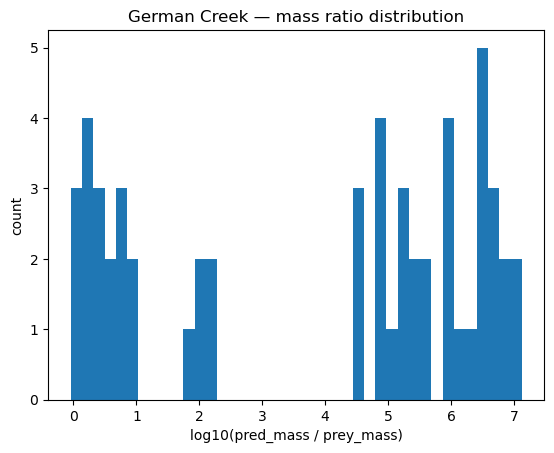

,con.taxonomy,res.taxonomy,pred_mass,prey_mass,n_rows,weight
3,Archichauliodes diversus,Pirara,0.015692,0.000164,1,9.995858e-01
0,Archichauliodes diversus,Costachorema xanthoptera,0.015692,0.000149,1,9.994192e-01
2,Archichauliodes diversus,Eukiefidrella,0.015692,0.000103,1,9.668796e-01
26,Hydrobiosis parumbripennis,Oligochaeta type II,0.000572,0.000009,1,9.561146e-01
1,Archichauliodes diversus,Deleatidium spp.,0.015692,0.000082,1,9.221361e-01
29,Hydrobiosis silvicola/clavigera,Eukiefidrella,0.000828,0.000103,1,2.935538e-01
20,Hydrobiosis parumbripennis,Austrosimulium australense,0.000572,0.000073,1,2.874346e-01
21,Hydrobiosis parumbripennis,Deleatidium spp.,0.000572,0.000082,1,2.554661e-01
22,Hydrobiosis parumbripennis,Eukiefidrella,0.000572,0.000103,1,1.996233e-01
30,Hydrobiosis silvicola/clavigera,Pirara,0.000828,0.000164,1,1.792999e-01


In [5]:
# Mass-ratio histogram to sanity-check the Tier-C driver variable
import matplotlib.pyplot as plt
z = np.log10(edgelist["pred_mass"] / edgelist["prey_mass"])
plt.figure()
plt.hist(z, bins=40)
plt.xlabel("log10(pred_mass / prey_mass)")
plt.ylabel("count")
plt.title(f"{meta['web_name']} — mass ratio distribution")
plt.show()

# Top weighted edges (plausibility)
edgelist_sorted = edgelist.sort_values("weight", ascending=False)
edgelist_sorted
# edgelist_sorted.head(10)
